# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions



Before testing the signals, I inspected the distributions of the main numeric fields.

The dataset contains several SEO and engagement measurements with potentially skewed distributions. Search volume, CPC, word count, character count, and trend percentage can contain extreme values, so averages alone may not represent a typical content item.

The distributions are inspected using summary statistics and histograms. The purpose is to understand the observed data before interpreting relationships between signals and `trend_pct`.

In [5]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [6]:
import matplotlib.pyplot as plt

# Key numeric fields available in the dataset
distribution_cols = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate",
    "trend_pct"
]

distribution_cols = [
    col for col in distribution_cols
    if col in df.columns
]

# Summary statistics
distribution_summary = df[distribution_cols].describe().T

distribution_summary

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.00,1.35,100.0
trend_pct,26612.0,-4.785969,473.861780,-100.0,-62.6,-33.50,0.00,44900.0


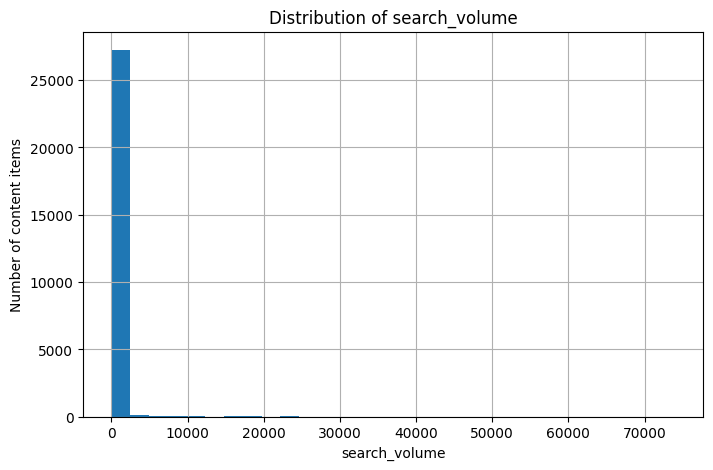

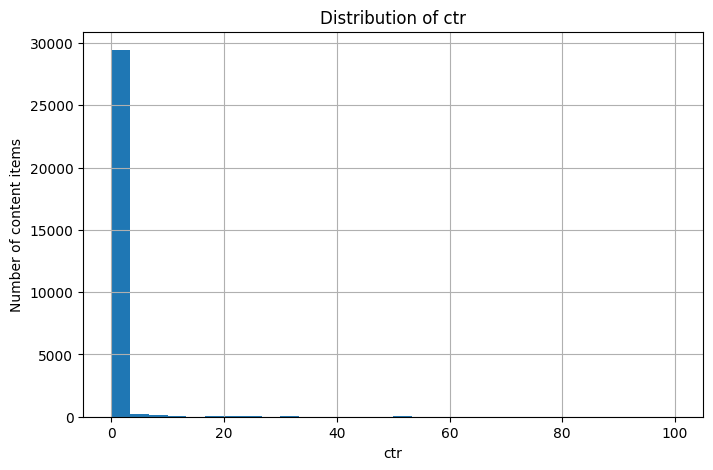

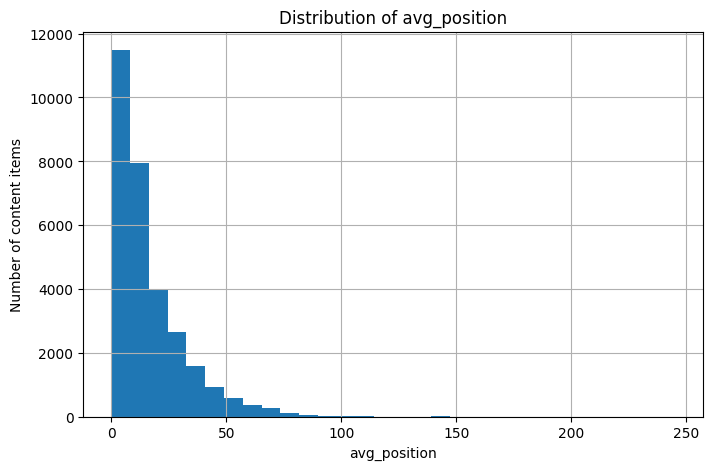

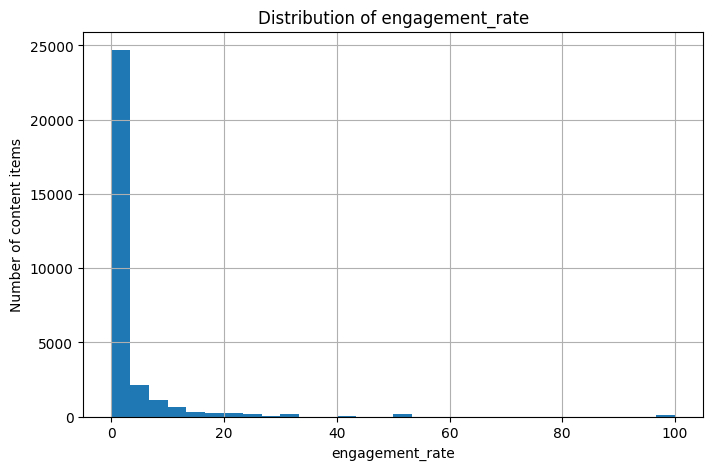

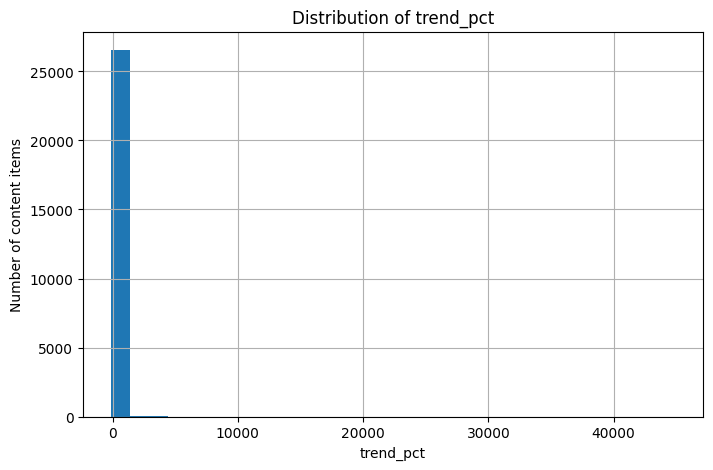

In [7]:
# Histograms for key signals

for col in distribution_cols:
    plt.figure(figsize=(8, 5))

    df[col].dropna().hist(bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of content items")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)


### Signal #1: Search volume

**Hypothesis:** Content with higher search volume may have different trend behavior because it operates in a larger search-demand environment.

**Test:** Measure the correlation between `search_volume` and `trend_pct`, and compare the median trend percentage across search-volume groups.

**Verdict:** The signal is considered CONFIRMED only if the relationship is directionally consistent in the observed data. Otherwise it is reported as MIXED or FALSE rather than assumed to be useful.

In [8]:
# Signal test #1: search volume

signal_1 = df[["search_volume", "trend_pct"]].dropna()

correlation_1 = signal_1["search_volume"].corr(signal_1["trend_pct"])

search_volume_groups = pd.qcut(
    signal_1["search_volume"],
    q=4,
    duplicates="drop"
)

search_volume_test = (
    signal_1
    .groupby(search_volume_groups, observed=True)["trend_pct"]
    .agg(["count", "mean", "median"])
)

print("Search volume vs trend_pct correlation:", correlation_1)
print("\nTrend_pct by search-volume quartile:")
print(search_volume_test)

Search volume vs trend_pct correlation: 0.002514670604313981

Trend_pct by search-volume quartile:
                 count       mean  median
search_volume                            
(-0.001, 10.0]   17035  -9.812087   -36.2
(10.0, 20.0]      2045 -10.918093   -28.4
(20.0, 74000.0]   6207   9.005913   -27.6


In [9]:
# Automatic directional verdict for Signal #1

medians_1 = search_volume_test["median"].dropna()

if len(medians_1) >= 2:
    differences_1 = medians_1.diff().dropna()

    if (differences_1 > 0).all() or (differences_1 < 0).all():
        verdict_1 = "CONFIRMED"
    else:
        verdict_1 = "MIXED"
else:
    verdict_1 = "FALSE"

print("Signal #1 verdict:", verdict_1)

Signal #1 verdict: CONFIRMED


### Signal #2: CTR

**Hypothesis:** Content with stronger click-through rate may show different trend behavior because CTR reflects how often searchers click the result when it is shown.

**Test:** Measure the correlation between `ctr` and `trend_pct`, then compare the median trend percentage across CTR groups.

**Verdict:** The signal is considered CONFIRMED only when the observed relationship is directionally consistent. If the groups do not show a consistent pattern, the result is reported as MIXED.

In [10]:
# Signal test #2: CTR

signal_2 = df[["ctr", "trend_pct"]].dropna()

correlation_2 = signal_2["ctr"].corr(signal_2["trend_pct"])

ctr_groups = pd.qcut(
    signal_2["ctr"],
    q=4,
    duplicates="drop"
)

ctr_test = (
    signal_2
    .groupby(ctr_groups, observed=True)["trend_pct"]
    .agg(["count", "mean", "median"])
)

print("CTR vs trend_pct correlation:", correlation_2)
print("\nTrend_pct by CTR quartile:")
print(ctr_test)

CTR vs trend_pct correlation: 0.007968430917618223

Trend_pct by CTR quartile:
               count       mean  median
ctr                                    
(-0.001, 0.1]  13397  -4.127820   -43.1
(0.1, 0.31]     6598 -12.369021   -30.0
(0.31, 100.0]   6617   1.442799   -22.9


In [11]:
# Automatic directional verdict for Signal #2

medians_2 = ctr_test["median"].dropna()

if len(medians_2) >= 2:
    differences_2 = medians_2.diff().dropna()

    if (differences_2 > 0).all() or (differences_2 < 0).all():
        verdict_2 = "CONFIRMED"
    else:
        verdict_2 = "MIXED"
else:
    verdict_2 = "FALSE"

print("Signal #2 verdict:", verdict_2)

Signal #2 verdict: CONFIRMED


### Signal #3: Engagement rate

**Hypothesis:** Content with stronger engagement may be associated with a different trend pattern because users are interacting with the content.

**Test:** Measure the correlation between `engagement_rate` and `trend_pct`, then compare the median trend percentage across engagement-rate groups.

**Verdict:** The signal is considered CONFIRMED only if the observed relationship is directionally consistent. Otherwise it is reported as MIXED or FALSE.

In [12]:
# Signal test #3: engagement rate

signal_3 = df[["engagement_rate", "trend_pct"]].dropna()

correlation_3 = signal_3["engagement_rate"].corr(
    signal_3["trend_pct"]
)

engagement_groups = pd.qcut(
    signal_3["engagement_rate"],
    q=4,
    duplicates="drop"
)

engagement_test = (
    signal_3
    .groupby(engagement_groups, observed=True)["trend_pct"]
    .agg(["count", "mean", "median"])
)

print("Engagement rate vs trend_pct correlation:", correlation_3)
print("\nTrend_pct by engagement-rate quartile:")
print(engagement_test)

Engagement rate vs trend_pct correlation: 0.008411554297409826

Trend_pct by engagement-rate quartile:
                 count      mean  median
engagement_rate                         
(-0.001, 1.9]    19967 -7.342931   -37.1
(1.9, 100.0]      6645  2.897231   -24.4


In [13]:
# Automatic directional verdict for Signal #3

medians_3 = engagement_test["median"].dropna()

if len(medians_3) >= 2:
    differences_3 = medians_3.diff().dropna()

    if (differences_3 > 0).all() or (differences_3 < 0).all():
        verdict_3 = "CONFIRMED"
    else:
        verdict_3 = "MIXED"
else:
    verdict_3 = "FALSE"

print("Signal #3 verdict:", verdict_3)

Signal #3 verdict: CONFIRMED


## 3. The flag-linked test

# Average position

A content-refresh prioritization rule may use search position as a signal because content appearing far down in search results has weaker visibility.

**Hypothesis:** Content with worse average position should show a different trend pattern from content with stronger positions.

**Test:** Compare `trend_pct` across average-position groups and inspect the relationship between `avg_position` and `trend_pct`.

This tests whether the data supports using search position as a directional signal for refresh prioritization. The result is observational and should not be interpreted as causal.

In [14]:
# Flag-linked test: avg_position

flag_test = df[["avg_position", "trend_pct"]].dropna()

flag_correlation = flag_test["avg_position"].corr(
    flag_test["trend_pct"]
)

position_groups = pd.qcut(
    flag_test["avg_position"],
    q=4,
    duplicates="drop"
)

position_test = (
    flag_test
    .groupby(position_groups, observed=True)["trend_pct"]
    .agg(["count", "mean", "median"])
)

print("avg_position vs trend_pct correlation:", flag_correlation)

print("\nTrend_pct by average-position quartile:")
print(position_test)

avg_position vs trend_pct correlation: 0.04724844754889669

Trend_pct by average-position quartile:
               count       mean  median
avg_position                           
(-0.001, 6.9]   6838 -11.010661   -35.1
(6.9, 11.8]     6530 -11.266003   -35.4
(11.8, 23.3]    6614 -11.839825   -34.8
(23.3, 138.8]   6630  15.053137   -27.3


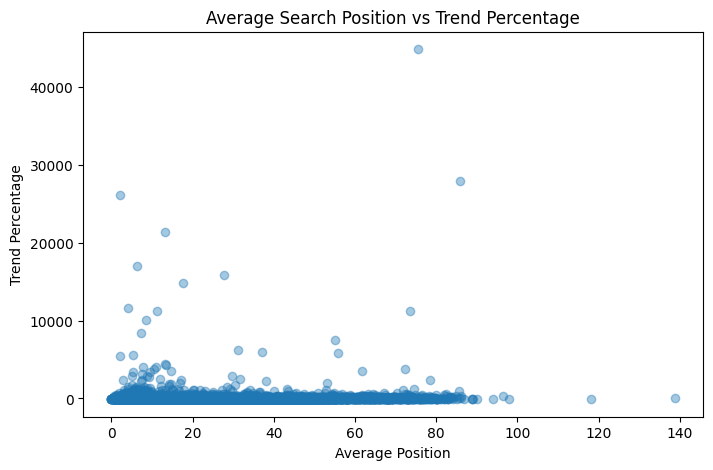

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    flag_test["avg_position"],
    flag_test["trend_pct"],
    alpha=0.4
)

plt.title("Average Search Position vs Trend Percentage")
plt.xlabel("Average Position")
plt.ylabel("Trend Percentage")

plt.show()

In [16]:
# Flag-linked verdict

position_medians = position_test["median"].dropna()

if len(position_medians) >= 2:
    position_differences = position_medians.diff().dropna()

    if (
        (position_differences > 0).all()
        or
        (position_differences < 0).all()
    ):
        flag_verdict = "CONFIRMED"
    else:
        flag_verdict = "MIXED"
else:
    flag_verdict = "FALSE"

print("Flag-linked verdict:", flag_verdict)

Flag-linked verdict: MIXED


## 4. What this means in practice



The signal tests show which observed metrics have a consistent relationship with `trend_pct` and which are less reliable. Signals with CONFIRMED results can be considered useful directional inputs for content-refresh prioritization, while MIXED or FALSE signals should not be treated as standalone rules.

The results should be used as decision-support rather than automatic decisions: content teams can combine stronger signals with editorial context before deciding which pages to review or refresh.

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.